# **BAJO CONTRASTE**



Mounted at /content/drive


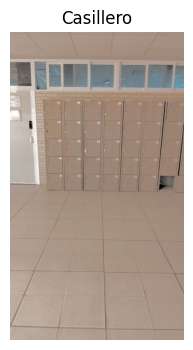

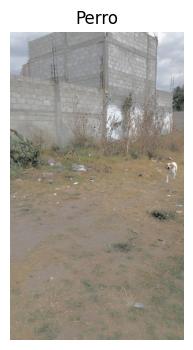

In [ ]:
from google.colab import drive   #Librería para conectar con Drive desde Google Colab
import cv2                       #Es OpenCV, la librería más potente para visión artificial
import matplotlib.pyplot as plt  #Librería para graficar y mostrar imágenes de forma visual
import os                        #Librería para manejar rutas de archivos

# Montar Drive
drive.mount('/content/drive')

# Ruta a mis imágenes
ruta_carpeta = "/content/drive/MyDrive/bajocontraste/"
foto1 = ruta_carpeta + "bajocontras1.jpeg"
foto2 = ruta_carpeta + "bajocontras2.jpeg"


# Función para mostrar la imagen
def mostrar_imagen(ruta, titulo):
    img = cv2.imread(ruta)
    if img is None:
        print(f"Error: No se encontró la imagen en {ruta}")

    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #Corrige los colores de azulado a natural
        plt.figure(figsize=(6,4))                  #lugar de visualización 6x4 pulgadas
        plt.imshow(img)                            #Dibuja la imagen en el lienzo
        plt.title(titulo)                          #Agrega el título que se elija
        plt.axis("off")                            #Limpia bordes para eliminar las coordenadas
        plt.show()                                 #Muestra el resultado final


# Primera imagen
mostrar_imagen(foto1, "Casillero")

# Segunda imagen
mostrar_imagen(foto2, "Perro")

/tmp/ipython-input-2793269510.py:20: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(gray.ravel(), 256, [0, 256], color='tab:blue', histtype='stepfilled')


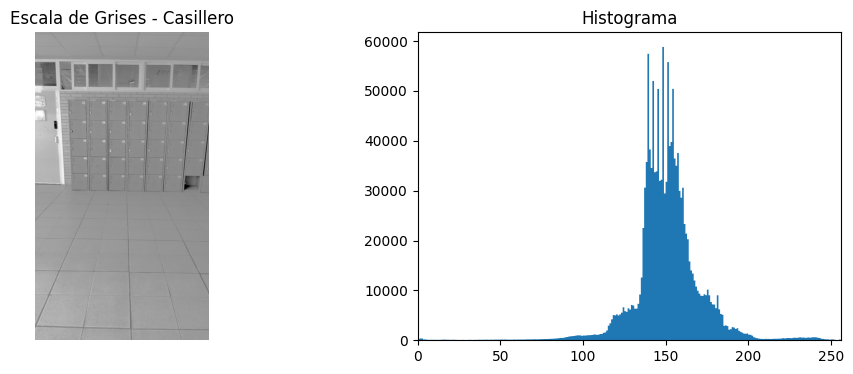

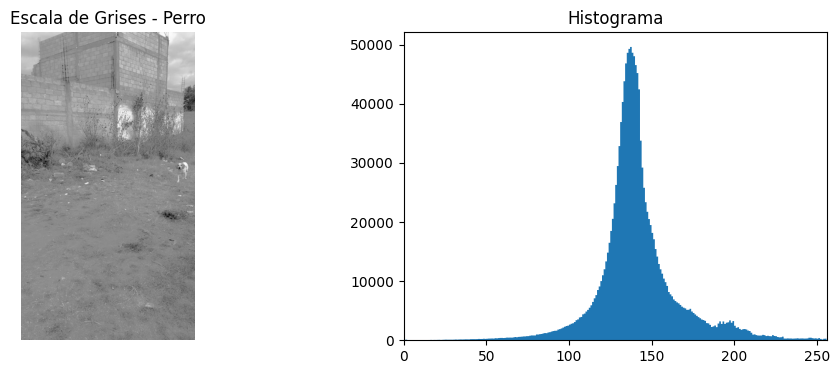

In [ ]:
# Función para el análisis
def mostrar_analisis_histograma(ruta, titulo):
    img = cv2.imread(ruta)
    if img is None:
        return

    # Convertimos a escala de grises para el análisis
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    plt.figure(figsize=(12, 4))

    # Imagen en Grises
    plt.subplot(1, 2, 1)
    plt.imshow(gray, cmap='gray')
    plt.title(f"Escala de Grises - {titulo}")
    plt.axis("off")

    # El Histograma
    plt.subplot(1, 2, 2)
    plt.hist(gray.ravel(), 256, [0, 256], color='tab:blue', histtype='stepfilled')
    plt.title("Histograma")
    plt.xlim([0, 256])      # Asegura que el eje X no tenga espacios vacíos a los lados
    plt.show()

# Ejecución
mostrar_analisis_histograma(foto1, "Casillero")
mostrar_analisis_histograma(foto2, "Perro")

#**Histograma + escala de grises**


**a) Analisis de brillo y contraste**

Hay bajo contraste

No tiene buena cantidad de detalles en tonos oscuros

No está subexpuesta (no acumula pixeles en la izquierda)

Podría estar ligeramente sobreexpuesta en zonas iluminadas (por el pico a la derecha)

**b) La imagen necesita:**

Nivelación

Mejorar contraste



# **Restauración de imagen y Reducción de ruido**

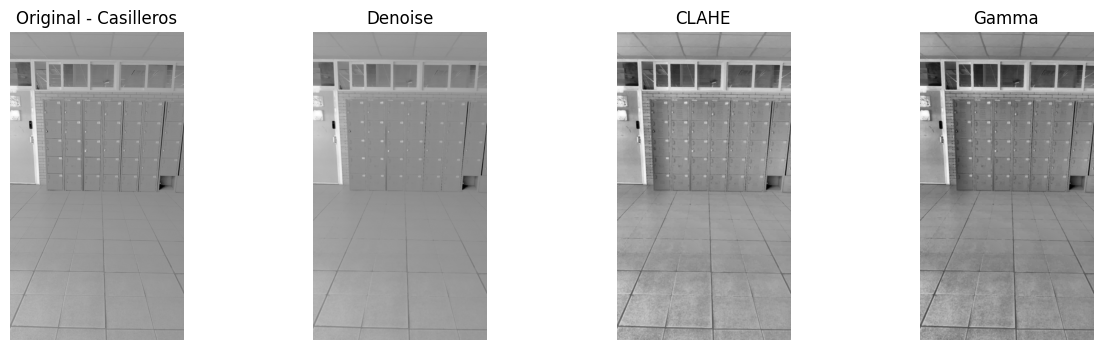

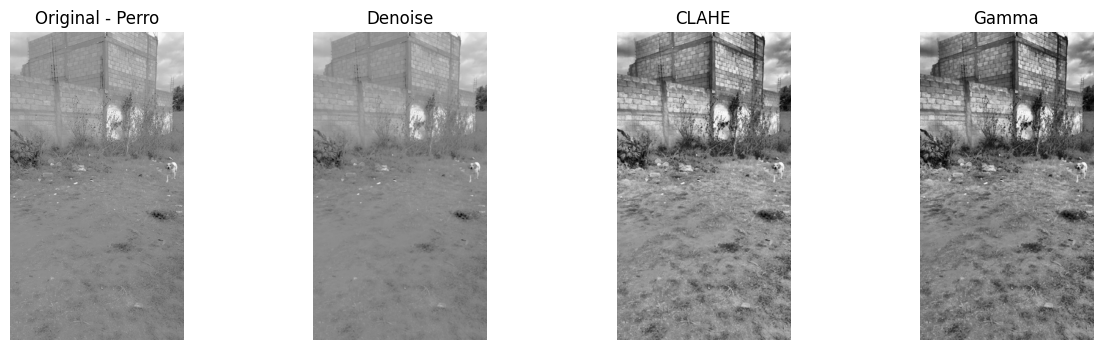

In [ ]:
import numpy as np

def restaurar_imagen(ruta, titulo):
    img = cv2.imread(ruta)
    if img is None: return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    denoise = cv2.medianBlur(gray, 5)                              #Suaviza la imagen ventana 5x5
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))     #Crea un ecualizador de histograma adaptativo
    contrast = clahe.apply(denoise)                                #mejora local, resalta detalles sin introducir tanto ruido
    gamma = 1.2                                                    #Normaliza, eleva los valores a potencia gamma cambiar la luminosidad, vuelve a escalar a 0–255
    gamma_corr = np.power(contrast/255.0, gamma) * 255
    gamma_corr = gamma_corr.astype(np.uint8)

    plt.figure(figsize=(15, 4))
    etapas = [(f"Original - {titulo}", gray), ("Denoise", denoise),
              ("CLAHE", contrast), ("Gamma", gamma_corr)]

    for i, (nombre, im) in enumerate(etapas):
        plt.subplot(1, 4, i+1)
        plt.imshow(im, cmap='gray')
        plt.title(nombre)
        plt.axis("off")
    plt.show()
    return gamma_corr

# PROCESAMOS AMBAS Y GUARDAMOS CADA UNA
res1 = restaurar_imagen(foto1, "Casilleros")
res2 = restaurar_imagen(foto2, "Perro")

# **Filtros espaciales (Sobel + Laplace)**

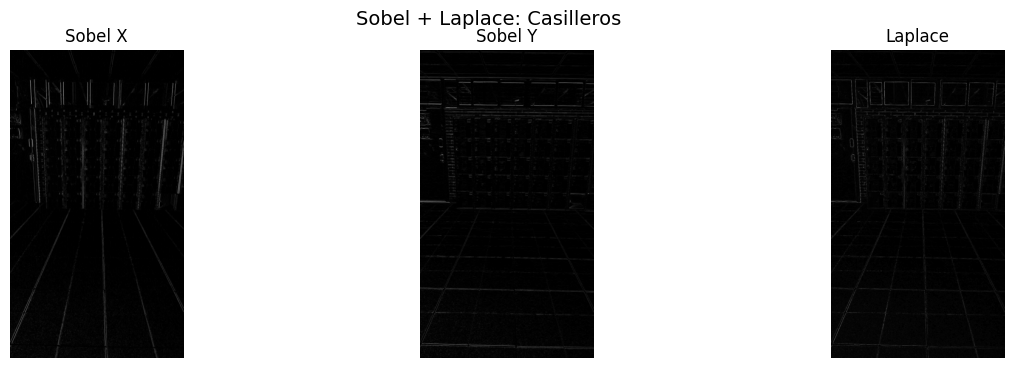

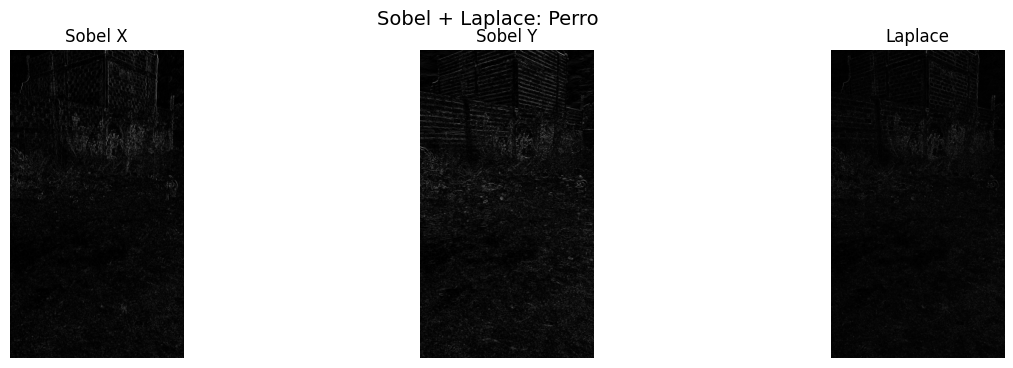

In [ ]:
def aplicar_sobel(gamma_corr, titulo_general):
    if gamma_corr is None: return

    sobelx = cv2.Sobel(gamma_corr, cv2.CV_64F, 1, 0, ksize=3)   #cambios horizontales
    sobely = cv2.Sobel(gamma_corr, cv2.CV_64F, 0, 1, ksize=3)   #Cambios verticales
    laplace = cv2.Laplacian(gamma_corr, cv2.CV_64F)             #Cambios en ambas direcciones

    plt.figure(figsize=(15,4))
    plt.suptitle(f"Sobel + Laplace: {titulo_general}", fontsize=14)
    for i, (t, im) in enumerate([("Sobel X", sobelx), ("Sobel Y", sobely), ("Laplace", laplace)]):
        plt.subplot(1, 3, i+1)
        plt.imshow(np.abs(im), cmap='gray')
        plt.title(t)
        plt.axis("off")
    plt.show()

# APLICAR A AMBAS
aplicar_sobel(res1, "Casilleros")
aplicar_sobel(res2, "Perro")

# **Transformada de Fourier (FFT) + Filtros**


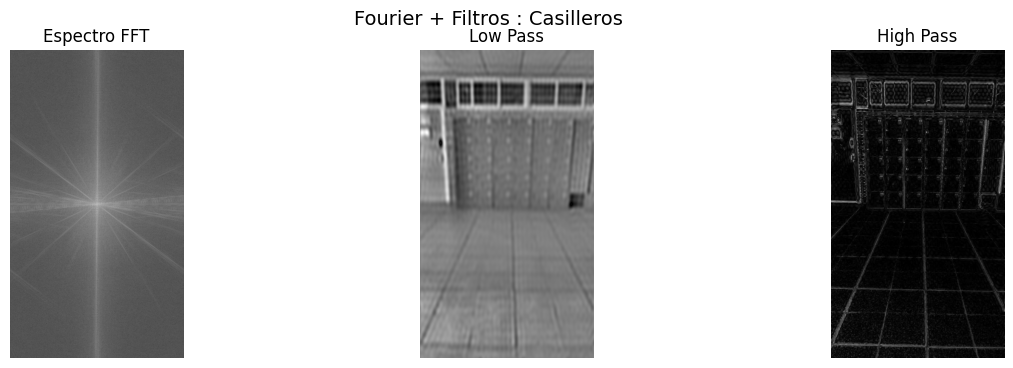

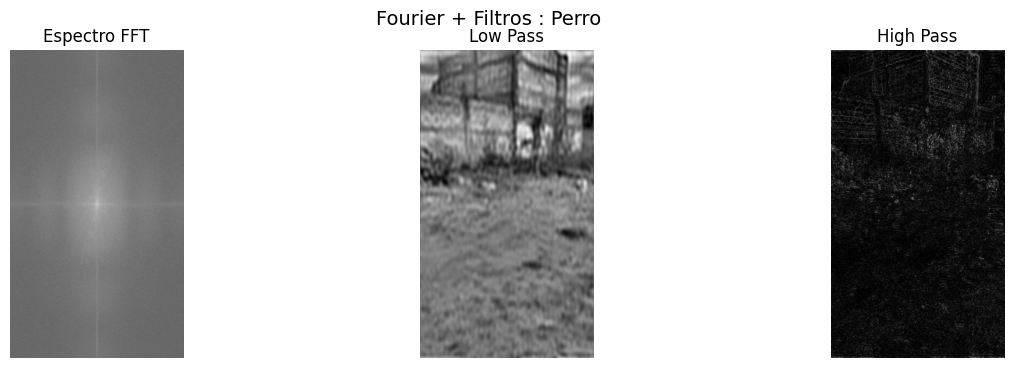

In [ ]:
def aplicar_fourier(imagen, titulo_general):
    if imagen is None: return

    f = np.fft.fft2(imagen)
    f_shift = np.fft.fftshift(f)
    magnitude = 20 * np.log(np.abs(f_shift))

    rows, cols = imagen.shape
    crow, ccol = rows//2, cols//2
    mask = np.zeros_like(imagen)
    r=40
    cv2.circle(mask, (ccol, crow), r, 1, -1)

    low_pass = f_shift * mask
    high_pass = f_shift * (1 - mask)

    low_img = np.abs(np.fft.ifft2(np.fft.ifftshift(low_pass)))
    high_img = np.abs(np.fft.ifft2(np.fft.ifftshift(high_pass)))

    plt.figure(figsize=(15, 4))
    plt.suptitle(f"Fourier + Filtros : {titulo_general}", fontsize=14)
    imgs_f = [("Espectro FFT", magnitude), ("Low Pass", low_img), ("High Pass", high_img)]
    for i, (t, imf) in enumerate(imgs_f):
        plt.subplot(1, 3, i+1)
        plt.imshow(imf, cmap='gray')
        plt.title(t)
        plt.axis("off")
    plt.show()

# APLICAR A AMBAS
aplicar_fourier(res1, "Casilleros")
aplicar_fourier(res2, "Perro")

# **Simulaciones Espectrales**

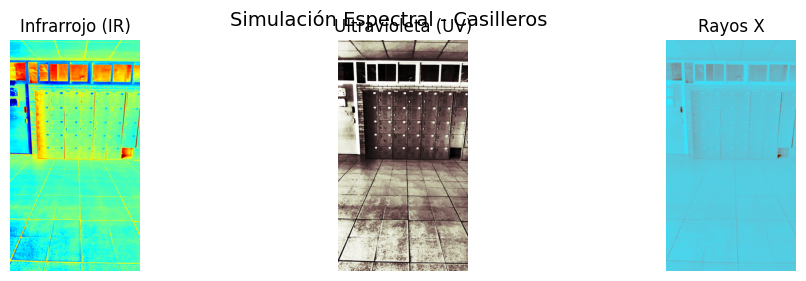

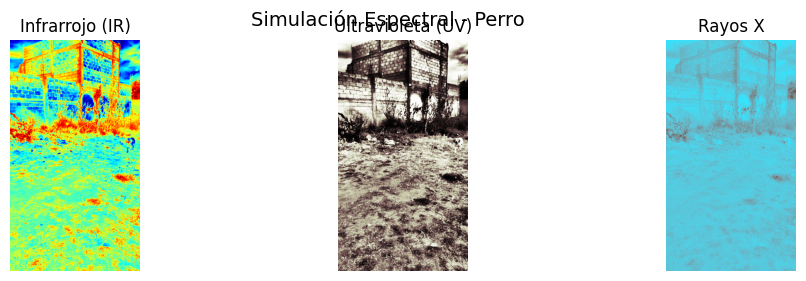

In [ ]:
def simulaciones_espectrales(imagen, titulo):
    if imagen is None:
        return

    # Asegurar escala de grises
    gray = imagen.copy()

    # Infrarrojo (IR)
    ir = cv2.applyColorMap(gray, cv2.COLORMAP_JET)

    # Ultravioleta (UV)
    uv = cv2.equalizeHist(gray)
    uv = cv2.applyColorMap(uv, cv2.COLORMAP_BONE)

    # Rayos X
    xray = np.log1p(gray.astype(np.float32))
    xray = xray / xray.max() * 255
    xray = xray.astype(np.uint8)
    xray = cv2.applyColorMap(xray, cv2.COLORMAP_CIVIDIS)

    # Mostrar
    plt.figure(figsize=(12, 3))
    plt.suptitle(f"Simulación Espectral - {titulo}", fontsize=14)

    for i, (t, im) in enumerate([
        ("Infrarrojo (IR)", ir),
        ("Ultravioleta (UV)", uv),
        ("Rayos X", xray)
    ]):
        plt.subplot(1, 3, i + 1)
        plt.imshow(im)
        plt.title(t)
        plt.axis("off")

    plt.show()

simulaciones_espectrales(res1, "Casilleros")
simulaciones_espectrales(res2, "Perro")